Análise de variáveis operacionais que podem explicar o NPS

Importando bibliotecas

In [28]:
#Libs

import pandas as pd
import numpy as np

#libs gráficas
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import pearsonr

#Avisos
import warnings
warnings.filterwarnings('ignore')

Lendo arquivo e exibindo os 5 primeiros

In [29]:
nps = pd.read_csv('desafio_nps_fase_1.csv')
nps.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


Analisando tamanho do dataset

In [30]:
nps.shape

(2500, 19)

Analisando tipo de dados

In [8]:
nps.dtypes

,0
customer_id,int64
customer_age,int64
customer_region,object
customer_tenure_months,int64
order_id,int64
order_value,float64
items_quantity,int64
discount_value,float64
payment_installments,int64
delivery_time_days,int64


Verificando valores nulos

In [9]:
nps.isnull().sum().sum()

np.int64(0)

Verificando colunas disponíveis

In [10]:
nps.columns

Index(['customer_id', 'customer_age', 'customer_region',
       'customer_tenure_months', 'order_id', 'order_value', 'items_quantity',
       'discount_value', 'payment_installments', 'delivery_time_days',
       'delivery_delay_days', 'freight_value', 'delivery_attempts',
       'customer_service_contacts', 'resolution_time_days', 'nps_score',
       'repeat_purchase_30d', 'complaints_count', 'csat_internal_score'],
      dtype='object')

Analisando dados

In [11]:
nps.describe().round(2)

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00
mean,1250.50,43.40,61.32,51250.50,434.26,3.47,29.75,6.00,8.02,2.19,38.22,2.01,1.52,5.49,4.38,0.09,4.15,2.94
std,721.83,14.89,34.48,721.83,289.77,1.69,29.23,3.16,3.77,1.45,12.08,0.82,1.23,3.46,2.51,0.28,1.78,2.38
min,1.00,18.00,1.00,50001.00,7.76,1.00,0.02,1.00,2.00,0.00,2.62,1.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,625.75,31.00,31.00,50625.75,220.24,2.00,8.88,3.00,5.00,1.00,29.93,1.00,1.00,2.00,2.60,0.00,3.00,0.70
50%,1250.50,43.00,62.00,51250.50,375.52,3.00,20.94,6.00,8.00,2.00,38.50,2.00,1.00,6.00,4.40,0.00,4.00,2.80
75%,1875.25,56.00,91.00,51875.25,577.29,5.00,40.83,9.00,11.00,3.00,46.27,3.00,2.00,8.00,6.10,0.00,5.00,4.80
max,2500.00,69.00,119.00,52500.00,1983.81,6.00,230.33,11.00,14.00,8.00,76.13,3.00,7.00,11.00,10.00,1.00,11.00,10.00


Análise do NPS com a variável de dias de atraso.

<Axes: xlabel='nps_score', ylabel='delivery_delay_days'>

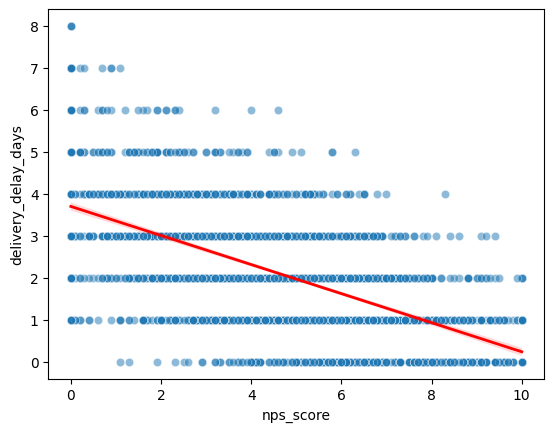

In [12]:
sns.scatterplot(data=nps, x="nps_score", y="delivery_delay_days", alpha=0.5)

sns.regplot(
         data=nps,
        x="nps_score",
        y="delivery_delay_days",
        scatter=False,            # não recria os pontos
        color="red",              # linha de tendência em vermelho
        line_kws={"linewidth": 2} # deixa a linha mais grossa
    )

Análise do NPS por região

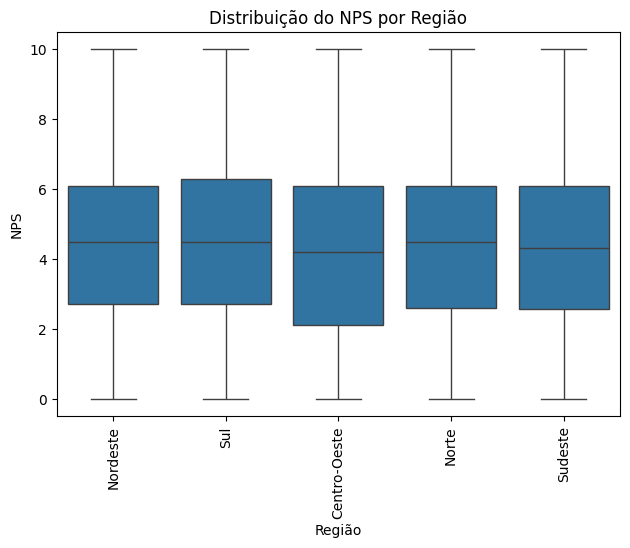

In [13]:
#NPS por região
plt.figure()
sns.boxplot(data=nps, x="customer_region", y="nps_score")
plt.title("Distribuição do NPS por Região")
plt.xlabel("Região")
plt.ylabel("NPS")
plt.tight_layout()
plt.xticks(rotation = 90);
plt.show()

Média de NPS de cada região

In [14]:
nps_regiao = nps.groupby("customer_region")["nps_score"].mean().sort_values()
nps_regiao

,nps_score
customer_region,
Centro-Oeste,4.209829
Sudeste,4.373846
Norte,4.382609
Nordeste,4.421649
Sul,4.490979


Gráfico do NPS médio por região

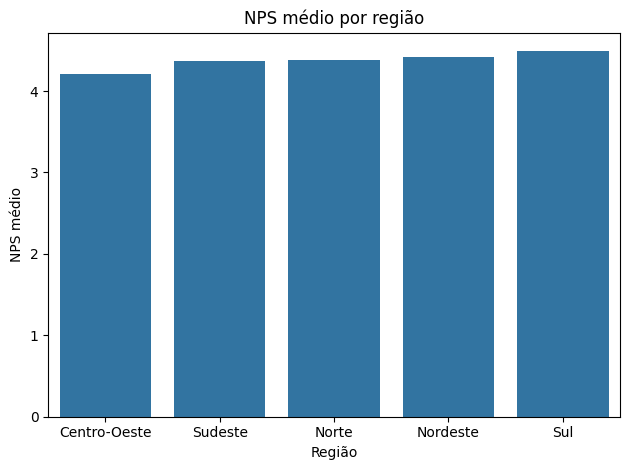

In [15]:
plt.figure()
sns.barplot(x=nps_regiao.index, y=nps_regiao.values)
plt.title("NPS médio por região")
plt.xlabel("Região")
plt.ylabel("NPS médio")
plt.tight_layout()
plt.show()

Análise da correlação de NPS, dias de atraso e contatos do cliente

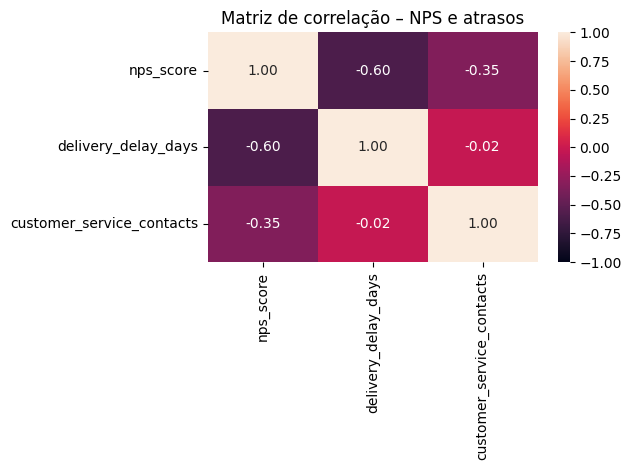

In [16]:
cols_corr = [c for c in ["nps_score", "delivery_delay_days", "customer_service_contacts"] if c in nps.columns]
corr = nps[cols_corr].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="rocket", vmin=-1, vmax=1)
plt.title("Matriz de correlação – NPS e atrasos")
plt.tight_layout()
plt.show()

Análise entre contagem de reclamações, dias de atraso e valor de frete.

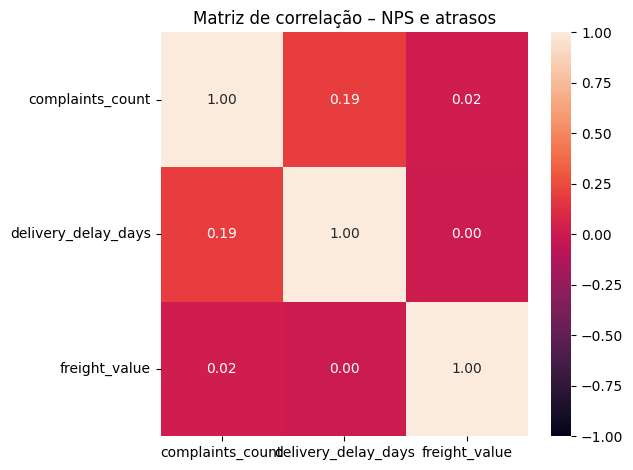

In [17]:
cols_corr = [c for c in ["complaints_count", "delivery_delay_days", "freight_value"] if c in nps.columns]
corr = nps[cols_corr].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="rocket", vmin=-1, vmax=1)
plt.title("Matriz de correlação – NPS e atrasos")
plt.tight_layout()
plt.show()

Análise de correlação de pearson com variáveis

In [18]:
for col in ["delivery_delay_days",
            "customer_service_contacts",
            "customer_tenure_months",
            "customer_age",
            "order_value",
            "items_quantity",
            "discount_value",
            "payment_installments",
            "delivery_time_days",
            "delivery_delay_days",
            "freight_value",
            "delivery_attempts",
            "customer_service_contacts",
            "resolution_time_days",
            "repeat_purchase_30d",
            "complaints_count"
             ]:

    corr, p = pearsonr(
        nps["nps_score"],
        nps[col]
    )

    print(f"{col}")
    print(f"Correlação: {corr:.2f}")
    print(f"P-value: {p:.5f}")
    print()

delivery_delay_days
Correlação: -0.60
P-value: 0.00000

customer_service_contacts
Correlação: -0.35
P-value: 0.00000

customer_tenure_months
Correlação: -0.01
P-value: 0.62744

customer_age
Correlação: -0.01
P-value: 0.61949

order_value
Correlação: 0.04
P-value: 0.06443

items_quantity
Correlação: 0.01
P-value: 0.56655

discount_value
Correlação: 0.03
P-value: 0.20957

payment_installments
Correlação: 0.02
P-value: 0.23584

delivery_time_days
Correlação: 0.00
P-value: 0.96313

delivery_delay_days
Correlação: -0.60
P-value: 0.00000

freight_value
Correlação: -0.04
P-value: 0.03996

delivery_attempts
Correlação: 0.03
P-value: 0.16649

customer_service_contacts
Correlação: -0.35
P-value: 0.00000

resolution_time_days
Correlação: -0.19
P-value: 0.00000

repeat_purchase_30d
Correlação: 0.57
P-value: 0.00000

complaints_count
Correlação: -0.50
P-value: 0.00000



Boxplot do NPS e dias de atraso

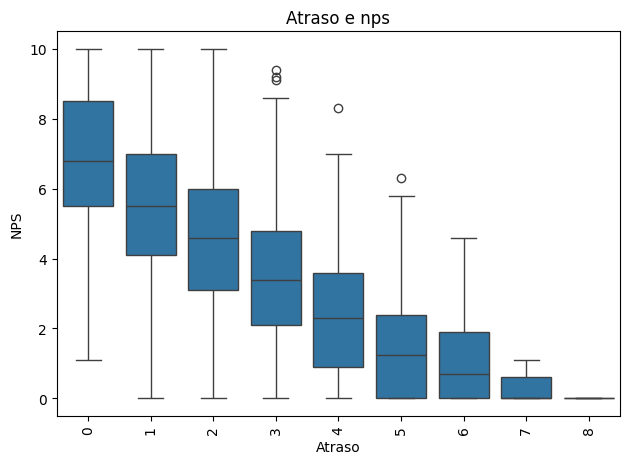

In [19]:
plt.figure()
sns.boxplot(data=nps, x="delivery_delay_days", y="nps_score")
plt.title("Distribuição de NPS por dias de atraso")
plt.xlabel("Atraso")
plt.ylabel("NPS")
plt.tight_layout()
plt.xticks(rotation = 90);
plt.show()

Boxplot de NPS por reclamações

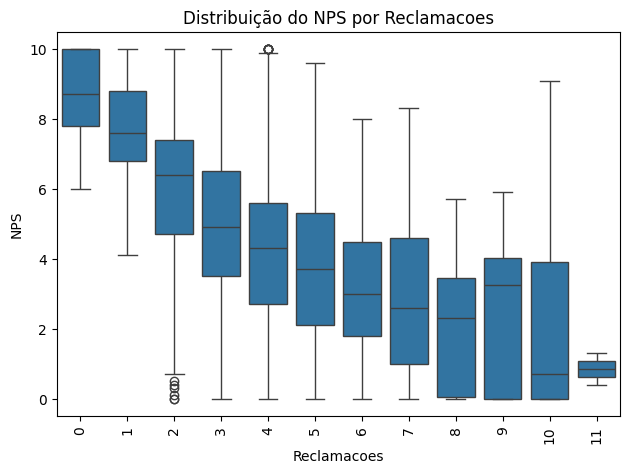

In [20]:
plt.figure()
sns.boxplot(data=nps, x="complaints_count", y="nps_score")
plt.title("Distribuição de NPS por reclamações")
plt.xlabel("Reclamações")
plt.ylabel("NPS")
plt.tight_layout()
plt.xticks(rotation = 90);
plt.show()

Boxplot de NPS por contatos do cliente

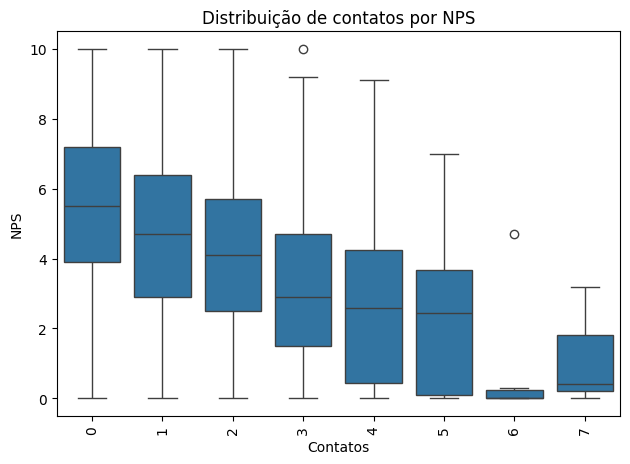

In [25]:
plt.figure()
sns.boxplot(data=nps, x="customer_service_contacts", y="nps_score")
plt.title("Distribuição de NPS por contatos do cliente")
plt.xlabel("Contatos")
plt.ylabel("NPS")
plt.tight_layout()
plt.xticks(rotation = 90);
plt.show()

Boxplot de NPS por idade

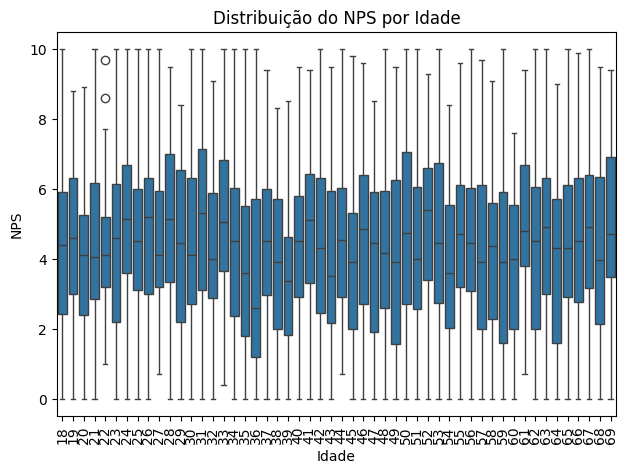

In [23]:
plt.figure()
sns.boxplot(data=nps, x="customer_age", y="nps_score")
plt.title("Distribuição de NPS por idade")
plt.xlabel("Idade")
plt.ylabel("NPS")
plt.tight_layout()
plt.xticks(rotation = 90);
plt.show()

Boxplot do NPS pela recompra

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

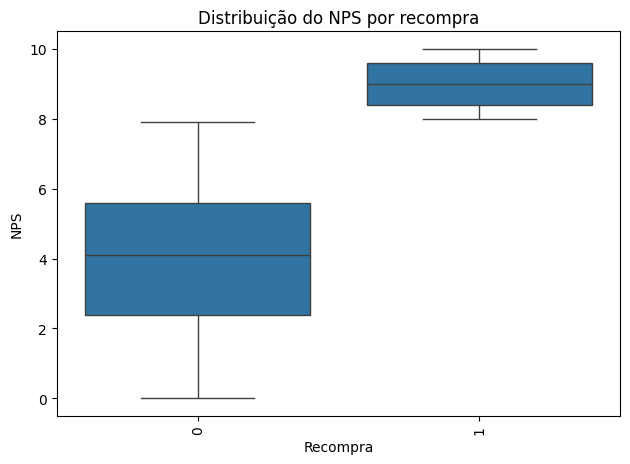

In [27]:
plt.figure()
sns.boxplot(data=nps, x="repeat_purchase_30d", y="nps_score")
plt.title("Distribuição do NPS por recompra")
plt.xlabel("Recompra")
plt.ylabel("NPS")
plt.tight_layout()
plt.xticks(rotation = 90);
plt.show()